Лабораторна робота No2. Метрики

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("KM-23-2.csv")
df

,GT,Model_1_0,Model_2_1
0,1,0.213394,0.999988
1,0,0.996161,0.003391
2,0,1.000000,0.000896
3,0,0.999142,0.000275
4,0,0.849776,0.003276
...,...,...,...
4395,0,0.945974,0.000088
4396,1,0.060282,0.913194
4397,1,0.003474,0.984063
4398,1,0.009708,0.996404


In [3]:
class_counts = df["GT"].value_counts()
class_counts

GT
1    2200
0    2200
Name: count, dtype: int64

Отже набір даних збалансований

Обчислити  всі  метрики  ( Accuracy,  Precision,  Recall,  F-Scores,  
Matthews  Correlation  Coefficient,  Balanced  Accuracy,  Youden’s  J  
statistics, Area Under Curve for Precision-Recall Curve, Area 
Under Curve for Receiver Operation Curve) для кожної моделі при 
різних значеннях порогу класифікатора ( крок зміни порогу 
обрати самостійно).

In [4]:
# Класифікація за порогом 0.5
threshold = 0.5
df["Pred_Model1"] = np.where(df["Model_1_0"] >= threshold, 0, 1)
df["Pred_Model2"] = np.where(df["Model_2_1"] >= threshold, 1, 0)

def accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

model1 = accuracy(df["GT"], df["Pred_Model1"])
model2 = accuracy(df["GT"], df["Pred_Model2"])

print(f"Accuracy Model 1: {model1:.4f}")
print(f"Accuracy Model 2 : {model2:.4f}")


Accuracy Model 1: 0.9911
Accuracy Model 2 : 0.9889


In [5]:
# Класифікація за порогом 0.5
threshold = 0.5
df["Pred_Model1"] = np.where(df["Model_1_0"] >= threshold, 0, 1)
df["Pred_Model2"] = np.where(df["Model_2_1"] >= threshold, 1, 0)


def accuracy(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    GM_pred = (TP + TN) / (TP + TN + FP + FN)

    return GM_pred, TP, TN, FP , FN

model1 = accuracy(df["GT"], df["Pred_Model1"])
model2 = accuracy(df["GT"], df["Pred_Model2"])

print("Accuracy Model 1 :")
for k in model1:
    print(f"{k:.4f}" )

print("\nAccuracy Model 2:")
for k in model2:
    print(f"{k:.4f}")



Accuracy Model 1 :
0.9911
2186.0000
2175.0000
25.0000
14.0000

Accuracy Model 2:
0.9889
2188.0000
2163.0000
37.0000
12.0000


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# Порогові значення
thresholds = np.arange(0, 1.01, 0.05)
y_true = df["GT"]

def calculate_metrics(y_true, y_probs, model_name="Model"):
    metrics_list = []

    for threshold in thresholds:
        y_pred = (y_probs >= threshold).astype(int)

        # TP, TN, FP, FN
        TP = ((y_pred == 1) & (y_true == 1)).sum()
        TN = ((y_pred == 0) & (y_true == 0)).sum()
        FP = ((y_pred == 1) & (y_true == 0)).sum()
        FN = ((y_pred == 0) & (y_true == 1)).sum()

        # Recall (Sensitivity)
        recall = recall_score(y_true, y_pred, zero_division=0)

        # Specificity (True Negative Rate)
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

        # Youden’s J statistic
        youden_j = recall + specificity - 1

        metrics = {
            'Threshold': threshold,
            'TP': TP,
            'TN': TN,
            'FP': FP,
            'FN': FN,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall,
            'F1 Score': f1_score(y_true, y_pred, zero_division=0),
            'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
            'MCC': matthews_corrcoef(y_true, y_pred),
            "Youden's J": youden_j,
        }

        metrics_list.append(metrics)

    return pd.DataFrame(metrics_list)

# Обробка моделей:
probs_model1 = 1 - df['Model_1_0']
metrics_model1 = calculate_metrics(y_true, probs_model1, "Model 1")

probs_model2 = df['Model_2_1']
metrics_model2 = calculate_metrics(y_true, probs_model2, "Model 2")

metrics_model1 
#metrics_model2

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,Youden's J
0,0.00,2200,0,2200,0,0.500000,0.500000,1.000000,0.666667,0.500000,0.000000,0.000000
1,0.05,2199,1079,1121,1,0.745000,0.662349,0.999545,0.796739,0.745000,0.569296,0.490000
2,0.10,2194,1351,849,6,0.805682,0.720999,0.997273,0.836925,0.805682,0.661883,0.611364
3,0.15,2193,2077,123,7,0.970455,0.946891,0.996818,0.971213,0.970455,0.942220,0.940909
4,0.20,2187,2163,37,13,0.988636,0.983363,0.994091,0.988698,0.988636,0.977331,0.977273
5,0.25,2187,2163,37,13,0.988636,0.983363,0.994091,0.988698,0.988636,0.977331,0.977273
6,0.30,2187,2163,37,13,0.988636,0.983363,0.994091,0.988698,0.988636,0.977331,0.977273
7,0.35,2187,2165,35,13,0.989091,0.984248,0.994091,0.989145,0.989091,0.978231,0.978182
8,0.40,2186,2169,31,14,0.989773,0.986017,0.993636,0.989812,0.989773,0.979575,0.979545
9,0.45,2186,2169,31,14,0.989773,0.986017,0.993636,0.989812,0.989773,0.979575,0.979545


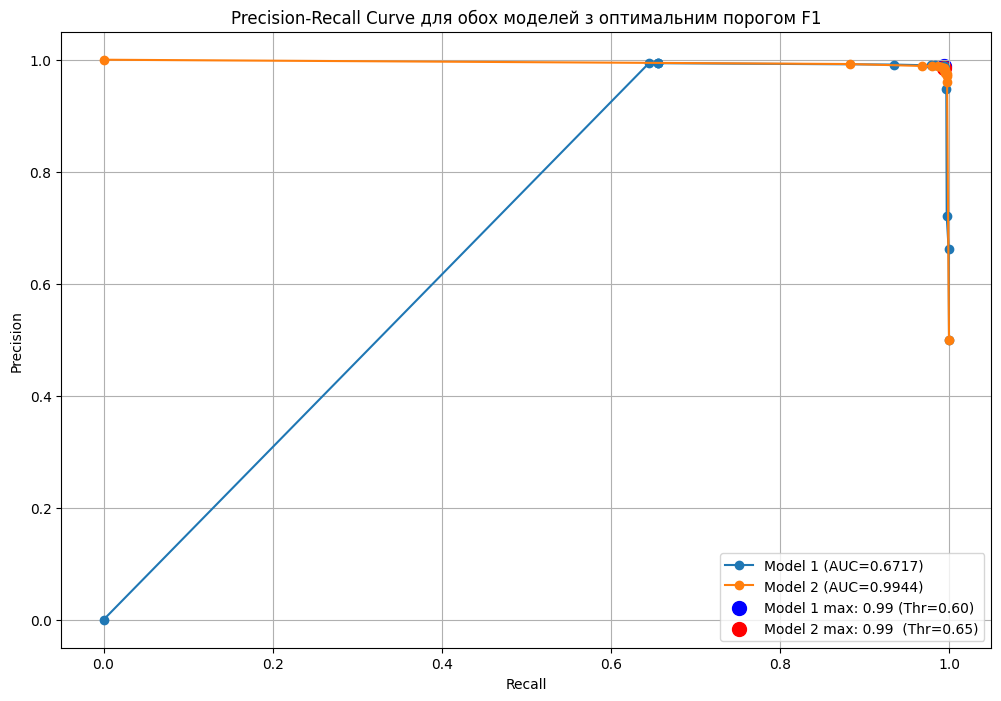

In [7]:
from sklearn.metrics import auc

recalls1 = metrics_model1["Recall"]
precisions1 = metrics_model1["Precision"]
recalls2 = metrics_model2["Recall"]
precisions2 = metrics_model2["Precision"]


# Обчислення площі під кривими
auc1 = auc(recalls1, precisions1)
auc2 = auc(recalls2, precisions2)

# Знаходження оптимального порогу для Model 1
best_f1_idx1 = metrics_model1["F1 Score"].idxmax()
best_f1_threshold1 = metrics_model1.loc[best_f1_idx1, "Threshold"]
best_f1_val1 = metrics_model1.loc[best_f1_idx1, "F1 Score"]

# Для Model 2
best_f1_idx2 = metrics_model2["F1 Score"].idxmax()
best_f1_threshold2 = metrics_model2.loc[best_f1_idx2, "Threshold"]
best_f1_val2 = metrics_model2.loc[best_f1_idx2, "F1 Score"]

plt.figure(figsize=(12, 8))
plt.plot(recalls1, precisions1, marker='o', label=f'Model 1 (AUC={auc1:.4f})')
plt.plot(recalls2, precisions2, marker='o', label=f'Model 2 (AUC={auc2:.4f})')

# Точка максимуму на кривій
plt.scatter(metrics_model1.loc[best_f1_idx1, "Recall"],
            metrics_model1.loc[best_f1_idx1, "Precision"],
            color='blue', s=100, label=f'Model 1 max: {best_f1_val1:.2f} (Thr={best_f1_threshold1:.2f})')

plt.scatter(metrics_model2.loc[best_f1_idx2, "Recall"],
            metrics_model2.loc[best_f1_idx2, "Precision"],
            color='red', s=100, label=f'Model 2 max: {best_f1_val2:.2f}  (Thr={best_f1_threshold2:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve для обох моделей з оптимальним порогом F1')
plt.grid(True)
plt.legend()
plt.show()


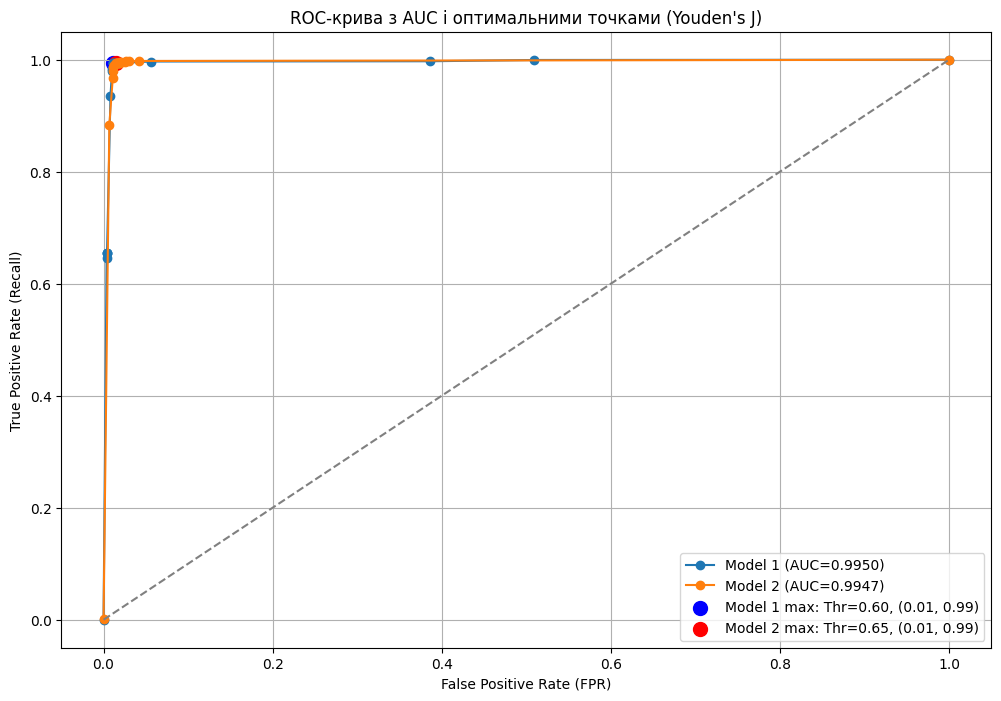

In [8]:
#ROC

# Для Model 1
fprs1 = metrics_model1["FP"] / (metrics_model1["FP"] + metrics_model1["TN"])
tprs1 = metrics_model1["Recall"]

# Для Model 2
fprs2 = metrics_model2["FP"] / (metrics_model2["FP"] + metrics_model2["TN"])
tprs2 = metrics_model2["Recall"]

# AUC
auc1 = auc(fprs1, tprs1)
auc2 = auc(fprs2, tprs2)

# Для Model 1
youden1 = tprs1 - fprs1
best_idx1 = youden1.idxmax()
best_threshold1 = metrics_model1.loc[best_idx1, "Threshold"]
best_fpr1 = fprs1[best_idx1]
best_tpr1 = tprs1[best_idx1]

# Для Model 2
youden2 = tprs2 - fprs2
best_idx2 = youden2.idxmax()
best_threshold2 = metrics_model2.loc[best_idx2, "Threshold"]
best_fpr2 = fprs2[best_idx2]
best_tpr2 = tprs2[best_idx2]


plt.figure(figsize=(12, 8))

# Побудова ROC-кривих
plt.plot(fprs1, tprs1, marker='o', label=f'Model 1 (AUC={auc1:.4f})')
plt.plot(fprs2, tprs2, marker='o', label=f'Model 2 (AUC={auc2:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Точка оптимального порогу для Model 1 з детальним підписом у легенді
plt.scatter(best_fpr1, best_tpr1, s=100, color='blue',
            label=f'Model 1 max: Thr={best_threshold1:.2f}, ({best_fpr1:.2f}, {best_tpr1:.2f})')

# Точка оптимального порогу для Model 2 з детальним підписом у легенді
plt.scatter(best_fpr2, best_tpr2, s=100, color='red',
            label=f'Model 2 max: Thr={best_threshold2:.2f}, ({best_fpr2:.2f}, {best_tpr2:.2f})')

# Підписи графіка
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title("ROC-крива з AUC і оптимальними точками (Youden's J)")
plt.grid(True)
plt.legend(loc="lower right")  # або 'best', 'upper left', тощо
plt.show()

 Збудувати на одному графіку в одній координатній системі 
(величина  порогу;  значення  метрики)  графіки  усіх  обчислених 
метрик, відмітивши певним чином максимальне значення кожної 
з них.

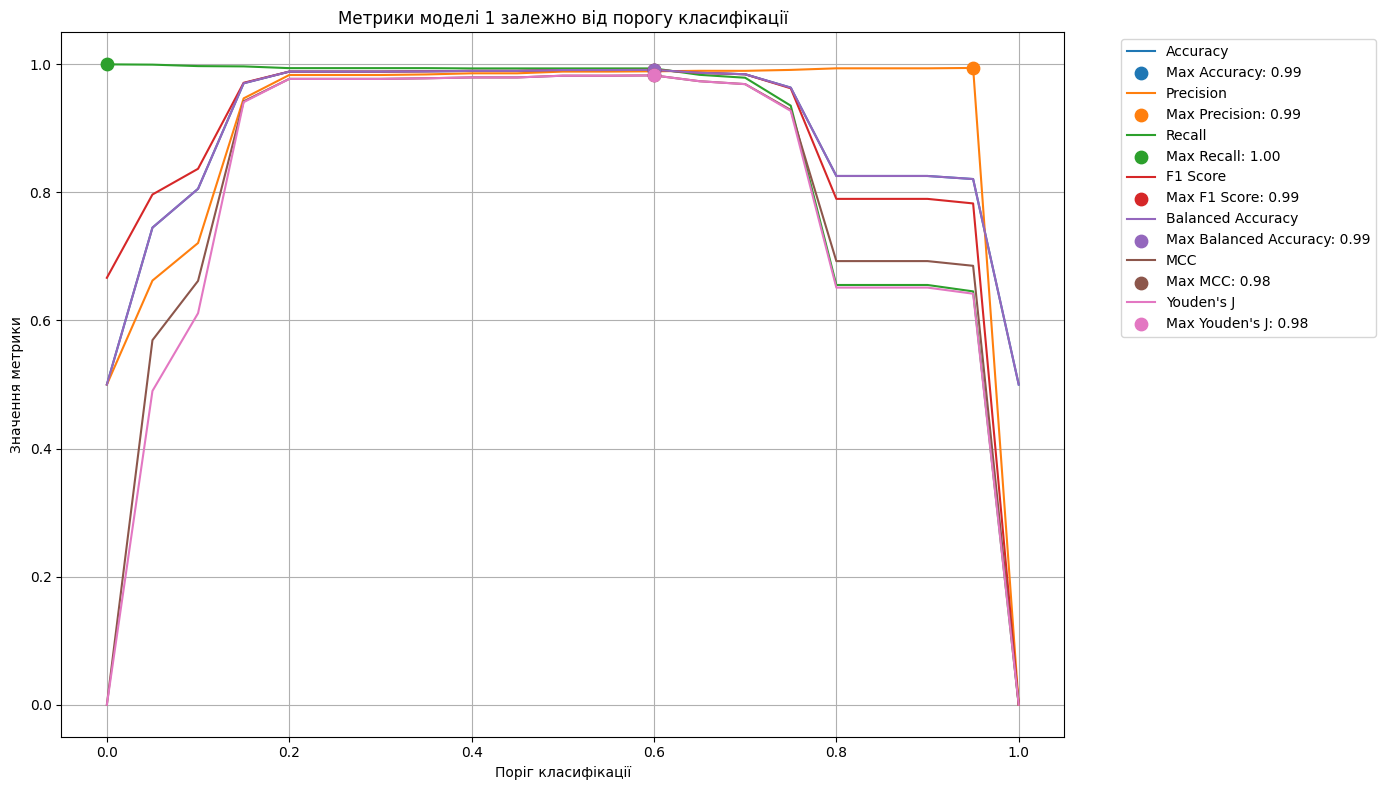

In [9]:
# Список метрик, які хочемо відобразити
metric_names = [
    "Accuracy", "Precision", "Recall", "F1 Score",
    "Balanced Accuracy", "MCC", "Youden's J"
]

plt.figure(figsize=(14, 8))

# Для кожної метрики побудувати графік залежності від порогу
for metric in metric_names:
    plt.plot(metrics_model1["Threshold"], metrics_model1[metric], label=metric)
    
    # Знаходимо максимум
    max_val = metrics_model1[metric].max()
    max_idx = metrics_model1[metric].idxmax()
    max_threshold = metrics_model1.loc[max_idx, "Threshold"]
    
    # Відмітити максимум на графіку
    plt.scatter(max_threshold, max_val, s=80, label=f"Max {metric}: {max_val:.2f}", zorder=5)

# Оформлення графіка
#plt.plot(metrics_model1["Threshold"], metrics_model1["Accuracy"], 
#        label="Accuracy",  linewidth=3, linestyle='--', marker='o')
plt.title("Метрики моделі 1 залежно від порогу класифікації")
plt.xlabel("Поріг класифікації")
plt.ylabel("Значення метрики")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

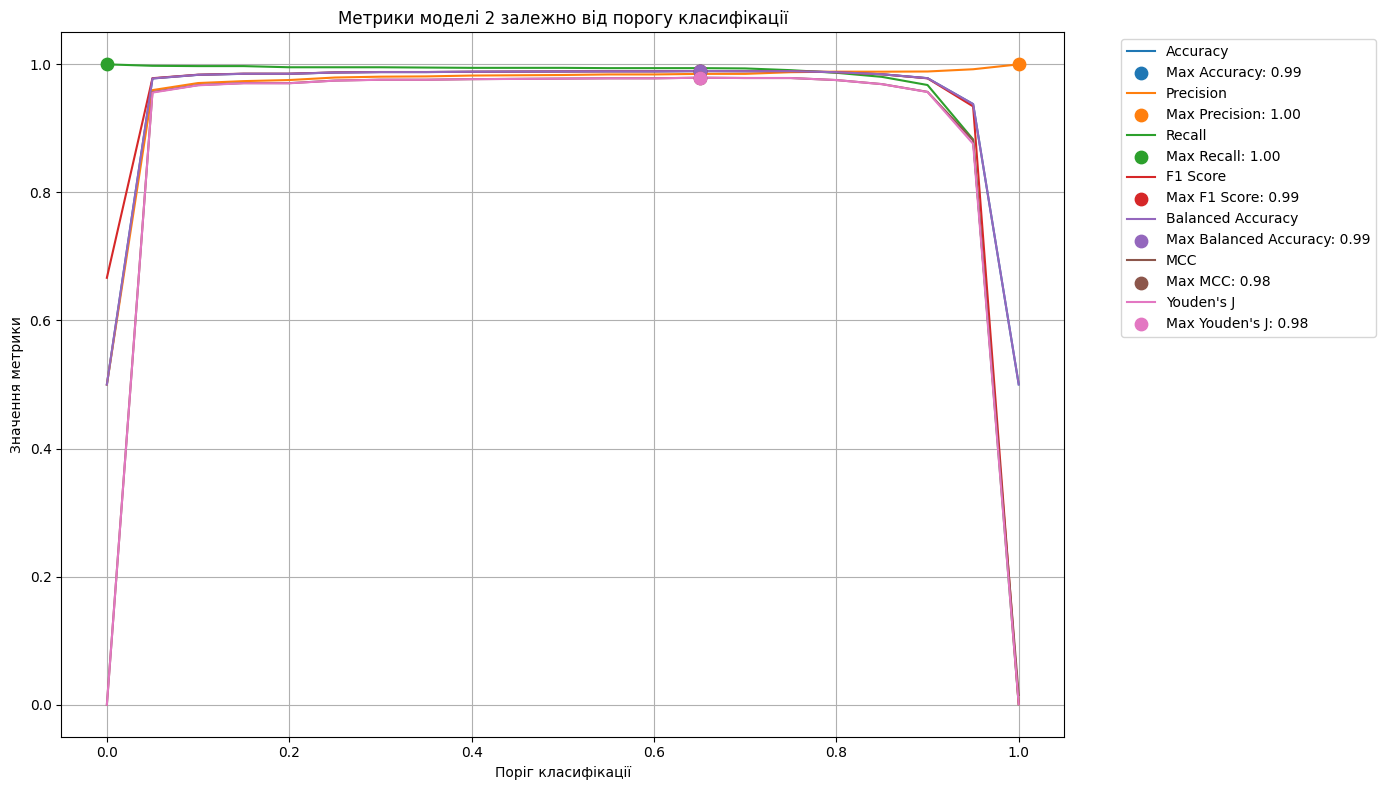

In [10]:

plt.figure(figsize=(14, 8))

# Для кожної метрики побудувати графік залежності від порогу
for metric in metric_names:
    plt.plot(metrics_model2["Threshold"], metrics_model2[metric], label=metric)
    
    # Знаходимо максимум
    max_val = metrics_model2[metric].max()
    max_idx = metrics_model2[metric].idxmax()
    max_threshold = metrics_model2.loc[max_idx, "Threshold"]
    
    # Відмітити максимум на графіку
    plt.scatter(max_threshold, max_val, s=80, label=f"Max {metric}: {max_val:.2f}", zorder=5)


plt.title("Метрики моделі 2 залежно від порогу класифікації")
plt.xlabel("Поріг класифікації")
plt.ylabel("Значення метрики")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Збудувати в координатах ( значення оцінки класифікаторів; 
кількість  об’єктів  кожного  класу)  окремі  для  кожного  класу 
графіки  кількості  об’єктів  та  відмітити  вертикальними  лініями 
оптимальні пороги відсічення для кожної метрики

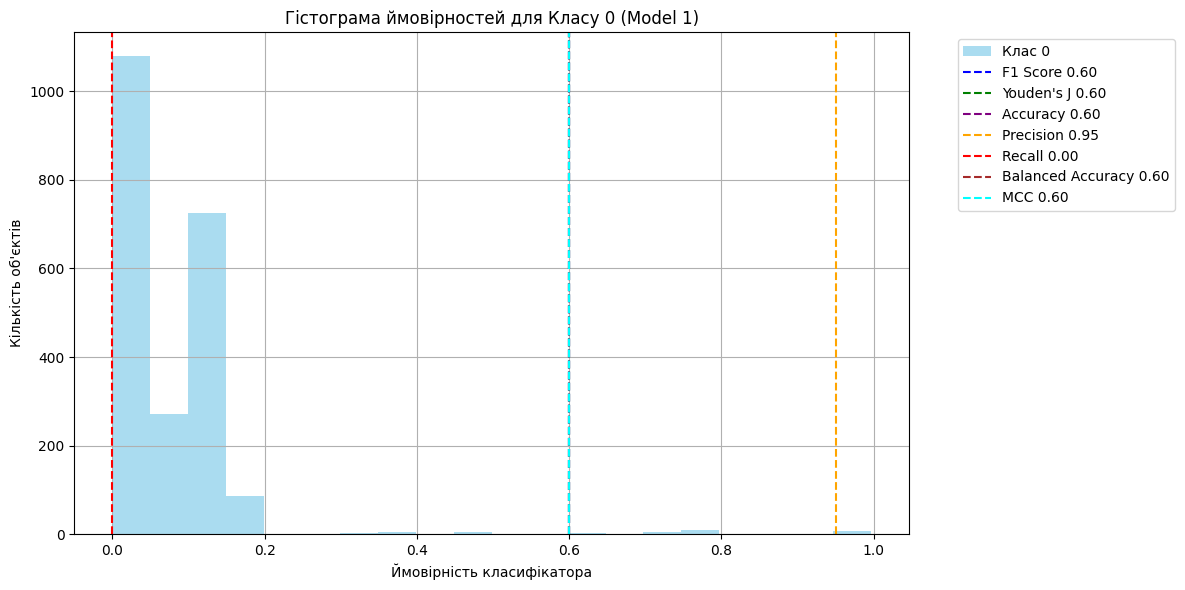

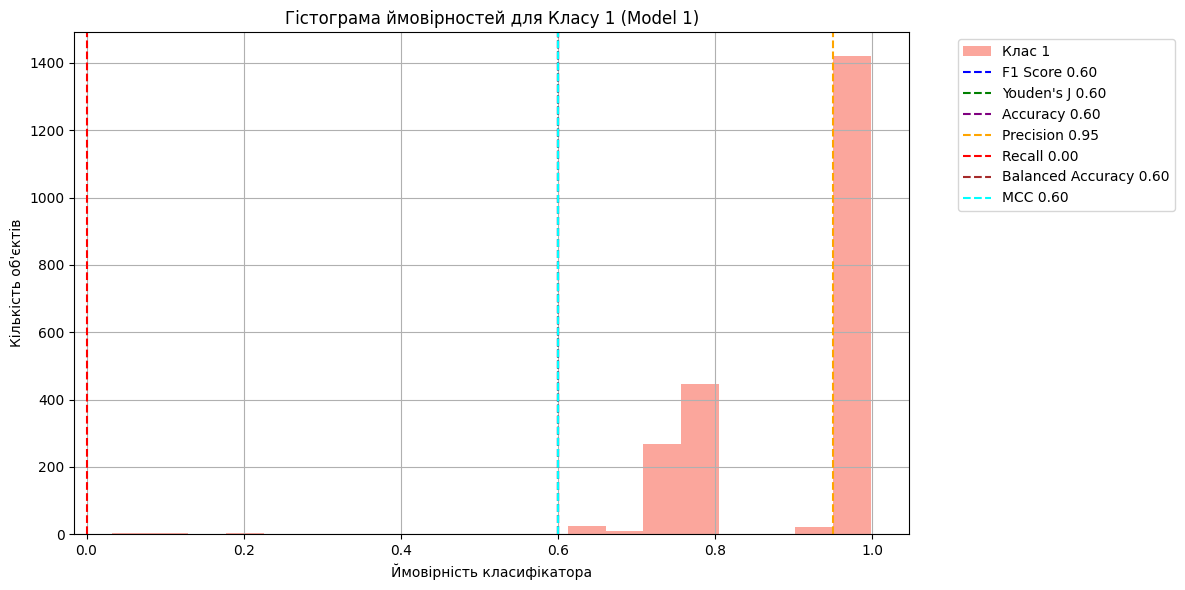

In [11]:
# 1. Дані для кожного класу
class_0 = probs_model1[y_true == 0]
class_1 = probs_model1[y_true == 1]

# 2. Знаходимо найкращі пороги для кожної метрики
best_thresholds = {
    "F1 Score": metrics_model1.loc[metrics_model1["F1 Score"].idxmax(), "Threshold"],
    "Youden's J": metrics_model1.loc[metrics_model1["Youden's J"].idxmax(), "Threshold"],
    "Accuracy": metrics_model1.loc[metrics_model1["Accuracy"].idxmax(), "Threshold"],
    "Precision": metrics_model1.loc[metrics_model1["Precision"].idxmax(), "Threshold"],
    "Recall": metrics_model1.loc[metrics_model1["Recall"].idxmax(), "Threshold"],
    "Balanced Accuracy": metrics_model1.loc[metrics_model1["Balanced Accuracy"].idxmax(), "Threshold"],
    "MCC": metrics_model1.loc[metrics_model1["MCC"].idxmax(), "Threshold"]
}

# 3. Побудова окремого графіка для Класу 0
plt.figure(figsize=(12, 6))
plt.hist(class_0, bins=20, color='skyblue', alpha=0.7, label="Клас 0")

# Вертикальні лінії з кольорами
colors = ['blue', 'green', 'purple', 'orange', 'red', 'brown', 'cyan']
for (metric, thr), color in zip(best_thresholds.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 0 (Model 1)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Побудова окремого графіка для Класу 1
plt.figure(figsize=(12, 6))
plt.hist(class_1, bins=20, color='salmon', alpha=0.7, label="Клас 1")

for (metric, thr), color in zip(best_thresholds.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 1 (Model 1)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


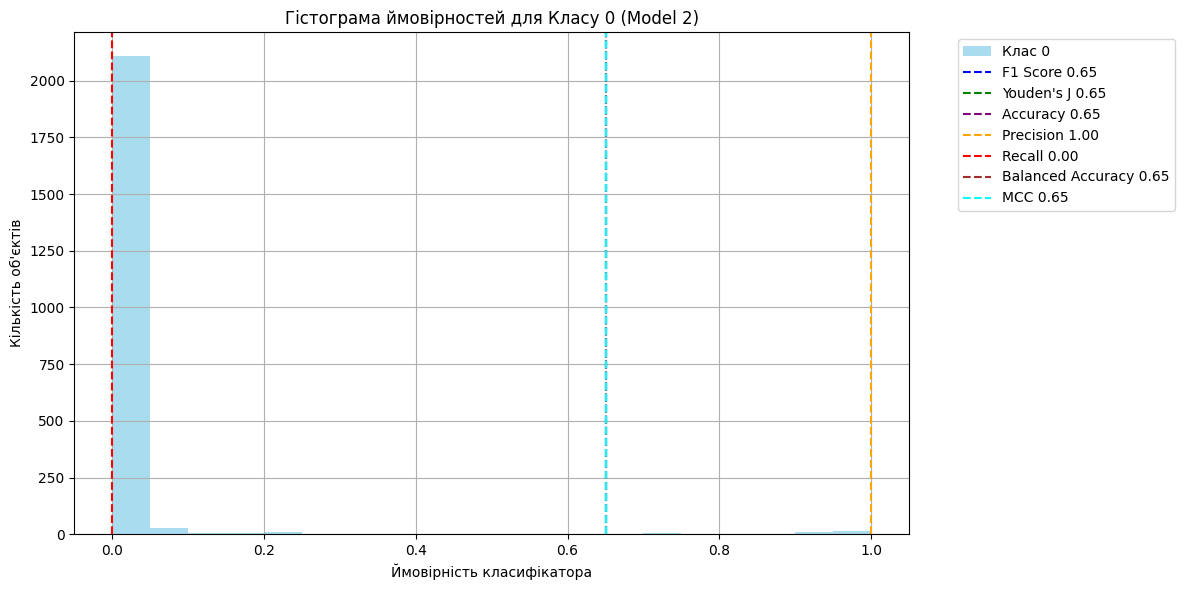

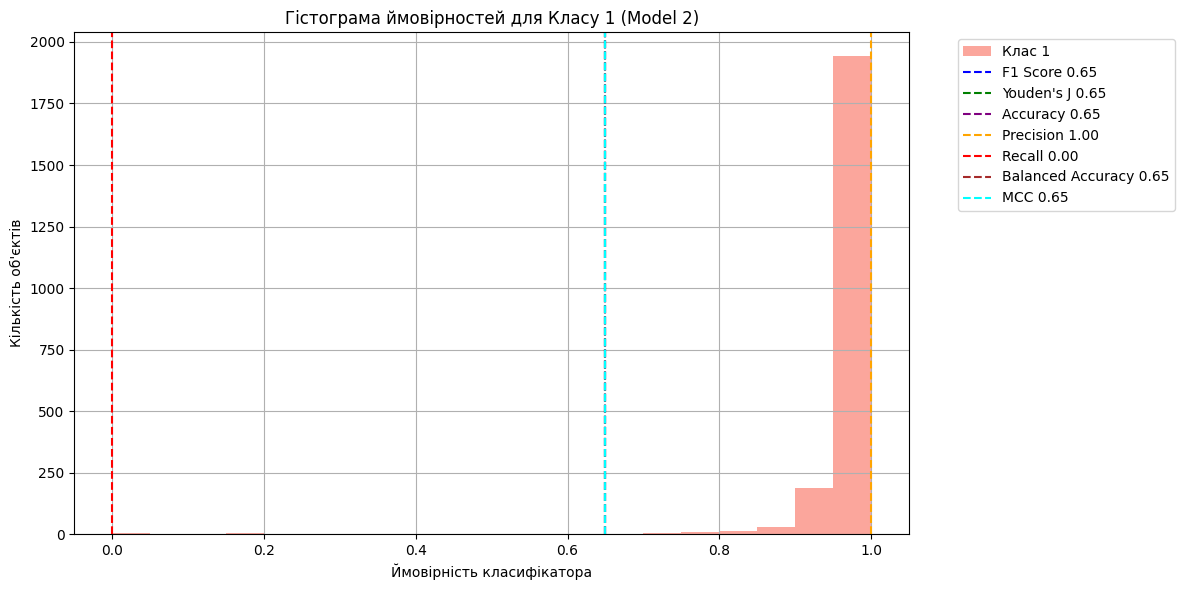

In [12]:
#Model 2
class_0_2 = probs_model2[y_true == 0]
class_1_2 = probs_model2[y_true == 1]

best_thresholds_2 = {
    "F1 Score": metrics_model2.loc[metrics_model2["F1 Score"].idxmax(), "Threshold"],
    "Youden's J": metrics_model2.loc[metrics_model2["Youden's J"].idxmax(), "Threshold"],
    "Accuracy": metrics_model2.loc[metrics_model2["Accuracy"].idxmax(), "Threshold"],
    "Precision": metrics_model2.loc[metrics_model2["Precision"].idxmax(), "Threshold"],
    "Recall": metrics_model2.loc[metrics_model2["Recall"].idxmax(), "Threshold"],
    "Balanced Accuracy": metrics_model2.loc[metrics_model2["Balanced Accuracy"].idxmax(), "Threshold"],
    "MCC": metrics_model2.loc[metrics_model2["MCC"].idxmax(), "Threshold"]
}

plt.figure(figsize=(12, 6))
plt.hist(class_0_2, bins=20, color='skyblue', alpha=0.7, label="Клас 0")

colors = ['blue', 'green', 'purple', 'orange', 'red', 'brown', 'cyan']
for (metric, thr), color in zip(best_thresholds_2.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 0 (Model 2)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.hist(class_1_2, bins=20, color='salmon', alpha=0.7, label="Клас 1")

for (metric, thr), color in zip(best_thresholds_2.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 1 (Model 2)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


4 Зробити висновки щодо якості моделей, визначити кращу модель. 
Model 2 краще, адже чіткіше відокремлює класи.

Створити    новий    набір    даних,    прибравши    з    початкового      набору   
(50 + 10К)% об’єктів класу 1, вибраних випадковим чином. Параметр К 
представляє собою залишок від ділення місяця народження студента на 
чотири  та має  визначатися  в  програмі  на  основі  дати  народження 
студента,  яка  задана  в  програмі  у  вигляді  текстової  змінної  формату 
‘DD-MM’.

In [13]:

birth_date = '02-06' 
month = int(birth_date.split('-')[1])
K = month % 4

remove_percent = 50 + 10 * K
print(f"Залишок K = {K}, потрібно видалити {remove_percent}% об’єктів класу 1")

class1_indices = df[df["GT"] == 1].index
n_to_remove = int(len(class1_indices) * remove_percent / 100)

remove_indices = np.random.choice(class1_indices, n_to_remove, replace=False)

df_reduced = df.drop(remove_indices) # видалення
print(f"Розмір початкового набору класу 1: {len(class1_indices)}")
print(f"Кількість класу 1 після фільтрації: {sum(df_reduced['GT'] == 1)}")


Залишок K = 2, потрібно видалити 70% об’єктів класу 1
Розмір початкового набору класу 1: 2200
Кількість класу 1 після фільтрації: 660


Вивести  відсоток  видалених  об’єктів  класу  1  та  кількість  елементів кожного класу після видалення

In [14]:
delete=100-remove_percent 
print(f"відсоток  видалених  об’єктів  класу 1: {delete} %")

df_reduced["GT"].value_counts()


відсоток  видалених  об’єктів  класу 1: 30 %


GT
0    2200
1     660
Name: count, dtype: int64

------------------------------------------------------------- повторення дій з п.3------------------------------------------------------------------------

In [15]:

y_true_reduced = df_reduced["GT"]

probs_model1_reduced = 1 - df_reduced['Model_1_0']
probs_model2_reduced = df_reduced['Model_2_1']

# Обчислення метрик
metrics_model1_reduced = calculate_metrics(y_true_reduced, probs_model1_reduced, "Model 1")
metrics_model2_reduced = calculate_metrics(y_true_reduced, probs_model2_reduced, "Model 2")

metrics_model1_reduced  
#  metrics_model2_reduced


,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,Youden's J
0,0.00,660,0,2200,0,0.230769,0.230769,1.000000,0.375000,0.500000,0.000000,0.000000
1,0.05,660,1079,1121,0,0.608042,0.370578,1.000000,0.540762,0.745227,0.426324,0.490455
2,0.10,657,1351,849,3,0.702098,0.436255,0.995455,0.606648,0.804773,0.514360,0.609545
3,0.15,657,2077,123,3,0.955944,0.842308,0.995455,0.912500,0.969773,0.888837,0.939545
4,0.20,656,2163,37,4,0.985664,0.946609,0.993939,0.969697,0.988561,0.960806,0.977121
5,0.25,656,2163,37,4,0.985664,0.946609,0.993939,0.969697,0.988561,0.960806,0.977121
6,0.30,656,2163,37,4,0.985664,0.946609,0.993939,0.969697,0.988561,0.960806,0.977121
7,0.35,656,2165,35,4,0.986364,0.949349,0.993939,0.971132,0.989015,0.962646,0.978030
8,0.40,655,2169,31,5,0.987413,0.954810,0.992424,0.973254,0.989167,0.965336,0.978333
9,0.45,655,2169,31,5,0.987413,0.954810,0.992424,0.973254,0.989167,0.965336,0.978333


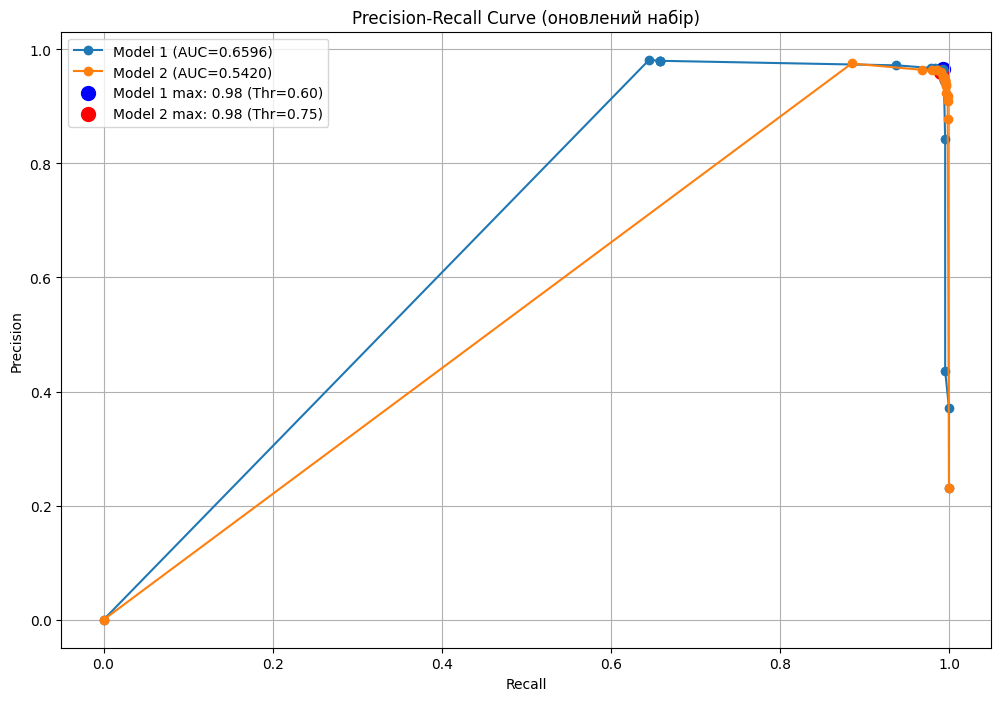

In [16]:

recalls1 = metrics_model1_reduced["Recall"]
precisions1 = metrics_model1_reduced["Precision"]
recalls2 = metrics_model2_reduced["Recall"]
precisions2 = metrics_model2_reduced["Precision"]

# AUC
auc1 = auc(recalls1, precisions1)
auc2 = auc(recalls2, precisions2)

# Оптимальні точки (максимум F1)
best_f1_idx1 = metrics_model1_reduced["F1 Score"].idxmax()
best_f1_threshold1 = metrics_model1_reduced.loc[best_f1_idx1, "Threshold"]
best_f1_val1 = metrics_model1_reduced.loc[best_f1_idx1, "F1 Score"]

best_f1_idx2 = metrics_model2_reduced["F1 Score"].idxmax()
best_f1_threshold2 = metrics_model2_reduced.loc[best_f1_idx2, "Threshold"]
best_f1_val2 = metrics_model2_reduced.loc[best_f1_idx2, "F1 Score"]

plt.figure(figsize=(12, 8))
plt.plot(recalls1, precisions1, marker='o', label=f'Model 1 (AUC={auc1:.4f})')
plt.plot(recalls2, precisions2, marker='o', label=f'Model 2 (AUC={auc2:.4f})')

plt.scatter(recalls1[best_f1_idx1], precisions1[best_f1_idx1], color='blue',
            s=100, label=f'Model 1 max: {best_f1_val1:.2f} (Thr={best_f1_threshold1:.2f})')
plt.scatter(recalls2[best_f1_idx2], precisions2[best_f1_idx2], color='red',
            s=100, label=f'Model 2 max: {best_f1_val2:.2f} (Thr={best_f1_threshold2:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (оновлений набір)')
plt.grid(True)
plt.legend()
plt.show()


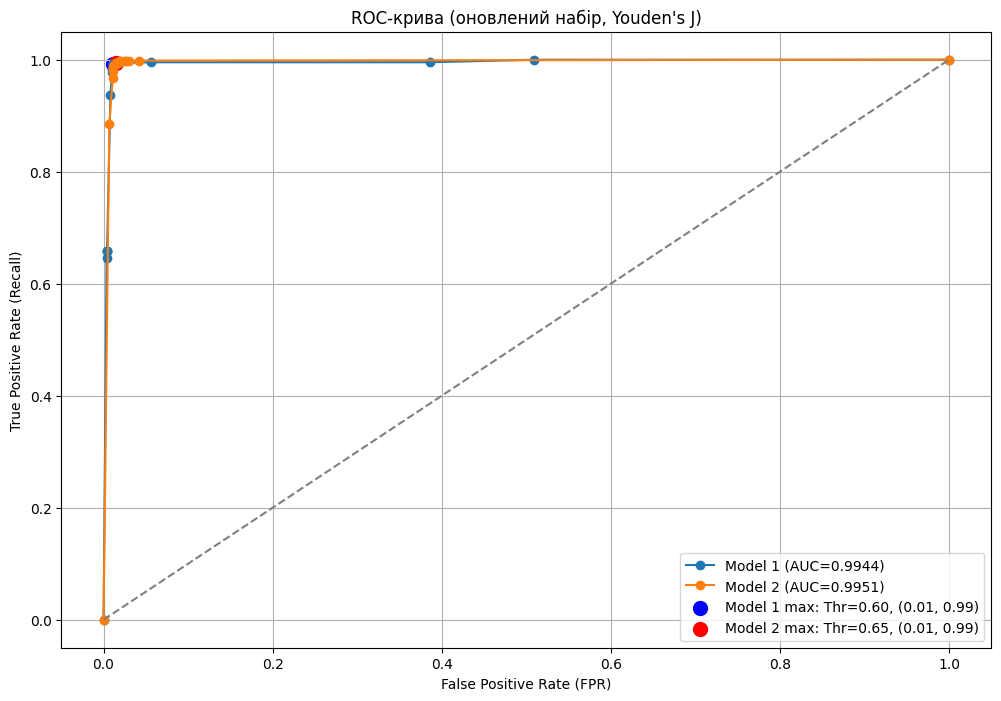

In [17]:
# FPR та TPR
fprs1 = metrics_model1_reduced["FP"] / (metrics_model1_reduced["FP"] + metrics_model1_reduced["TN"])
tprs1 = metrics_model1_reduced["Recall"]

fprs2 = metrics_model2_reduced["FP"] / (metrics_model2_reduced["FP"] + metrics_model2_reduced["TN"])
tprs2 = metrics_model2_reduced["Recall"]

# AUC
auc_roc1 = auc(fprs1, tprs1)
auc_roc2 = auc(fprs2, tprs2)

# Youden's J = TPR - FPR
youden1 = tprs1 - fprs1
youden2 = tprs2 - fprs2

best_idx1 = youden1.idxmax()
best_threshold1 = metrics_model1_reduced.loc[best_idx1, "Threshold"]
best_fpr1 = fprs1[best_idx1]
best_tpr1 = tprs1[best_idx1]

best_idx2 = youden2.idxmax()
best_threshold2 = metrics_model2_reduced.loc[best_idx2, "Threshold"]
best_fpr2 = fprs2[best_idx2]
best_tpr2 = tprs2[best_idx2]

plt.figure(figsize=(12, 8))
plt.plot(fprs1, tprs1, marker='o', label=f'Model 1 (AUC={auc_roc1:.4f})')
plt.plot(fprs2, tprs2, marker='o', label=f'Model 2 (AUC={auc_roc2:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.scatter(best_fpr1, best_tpr1, s=100, color='blue',
            label=f'Model 1 max: Thr={best_threshold1:.2f}, ({best_fpr1:.2f}, {best_tpr1:.2f})')
plt.scatter(best_fpr2, best_tpr2, s=100, color='red',
            label=f'Model 2 max: Thr={best_threshold2:.2f}, ({best_fpr2:.2f}, {best_tpr2:.2f})')

# Оформлення
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title("ROC-крива (оновлений набір, Youden's J)")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()


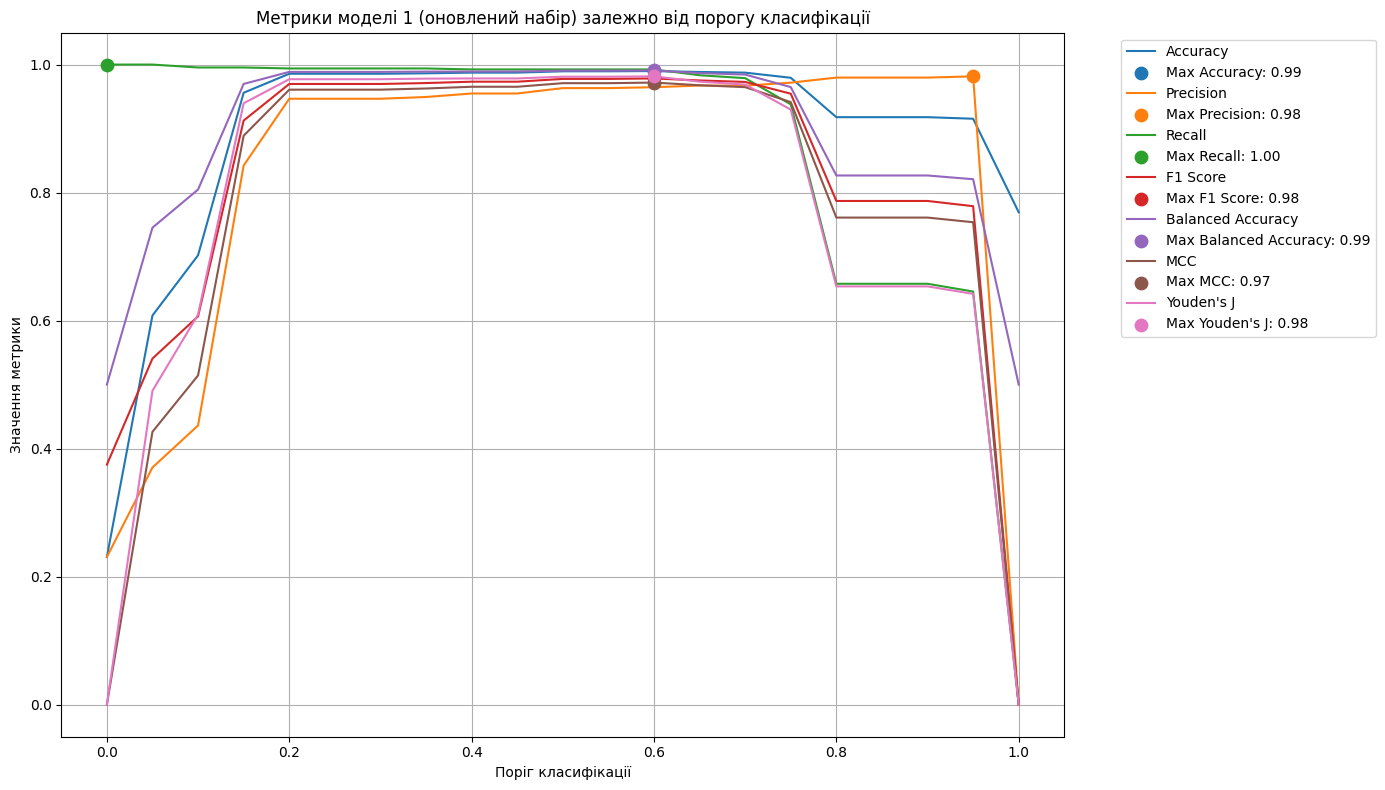

In [18]:
metric_names = [
    "Accuracy", "Precision", "Recall", "F1 Score",
    "Balanced Accuracy", "MCC", "Youden's J"
]

plt.figure(figsize=(14, 8))

for metric in metric_names:
    plt.plot(metrics_model1_reduced["Threshold"], metrics_model1_reduced[metric], label=metric)
    
    max_val = metrics_model1_reduced[metric].max()
    max_idx = metrics_model1_reduced[metric].idxmax()
    max_threshold = metrics_model1_reduced.loc[max_idx, "Threshold"]
    
    plt.scatter(max_threshold, max_val, s=80, label=f"Max {metric}: {max_val:.2f}", zorder=5)

plt.title("Метрики моделі 1 (оновлений набір) залежно від порогу класифікації")
plt.xlabel("Поріг класифікації")
plt.ylabel("Значення метрики")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


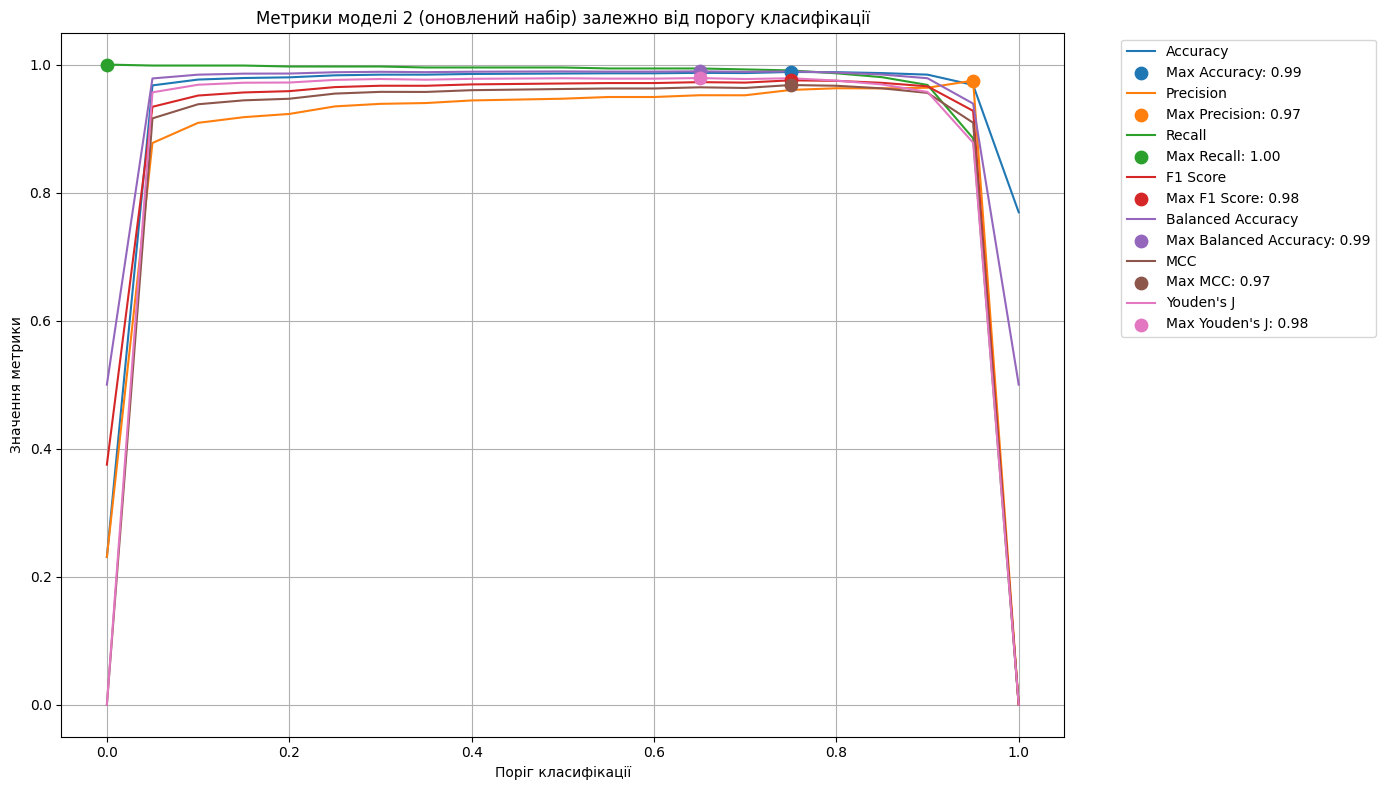

In [19]:
plt.figure(figsize=(14, 8))

for metric in metric_names:
    plt.plot(metrics_model2_reduced["Threshold"], metrics_model2_reduced[metric], label=metric)
    
    max_val = metrics_model2_reduced[metric].max()
    max_idx = metrics_model2_reduced[metric].idxmax()
    max_threshold = metrics_model2_reduced.loc[max_idx, "Threshold"]
    
    plt.scatter(max_threshold, max_val, s=80, label=f"Max {metric}: {max_val:.2f}", zorder=5)

plt.title("Метрики моделі 2 (оновлений набір) залежно від порогу класифікації")
plt.xlabel("Поріг класифікації")
plt.ylabel("Значення метрики")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


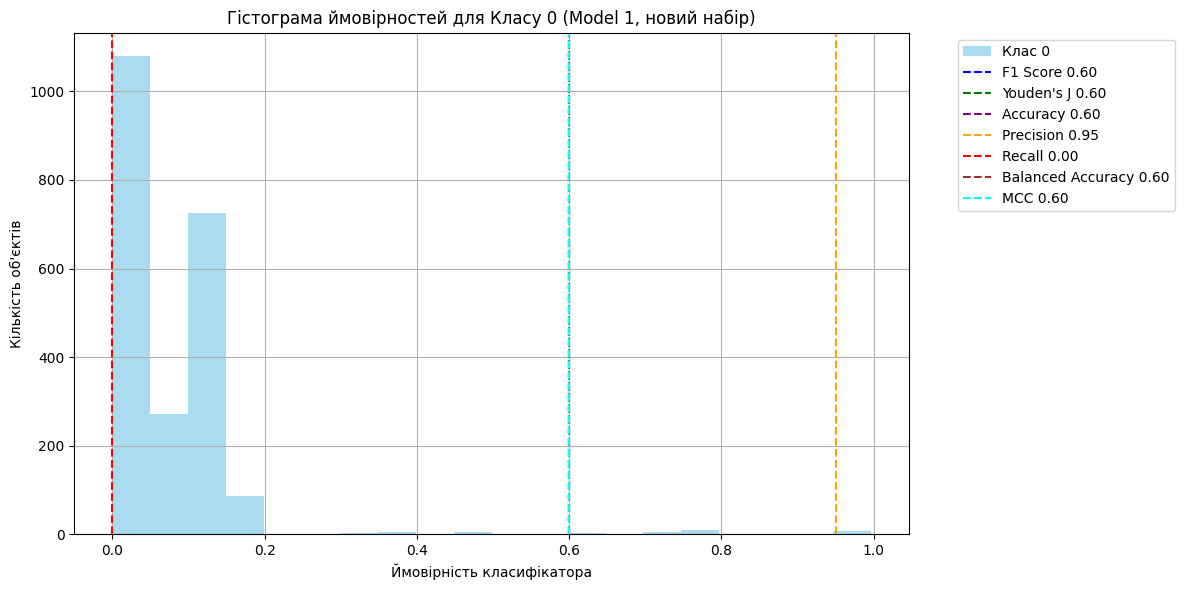

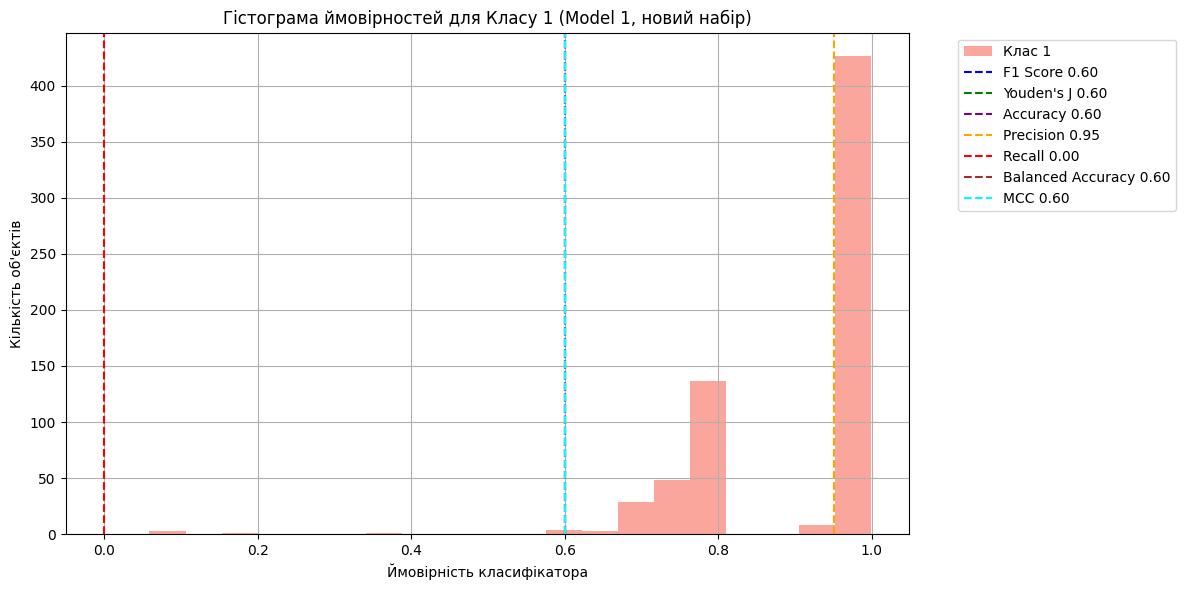

In [20]:
class_0_r = probs_model1_reduced[y_true_reduced == 0]
class_1_r = probs_model1_reduced[y_true_reduced == 1]

best_thresholds_r = {
    "F1 Score": metrics_model1_reduced.loc[metrics_model1_reduced["F1 Score"].idxmax(), "Threshold"],
    "Youden's J": metrics_model1_reduced.loc[metrics_model1_reduced["Youden's J"].idxmax(), "Threshold"],
    "Accuracy": metrics_model1_reduced.loc[metrics_model1_reduced["Accuracy"].idxmax(), "Threshold"],
    "Precision": metrics_model1_reduced.loc[metrics_model1_reduced["Precision"].idxmax(), "Threshold"],
    "Recall": metrics_model1_reduced.loc[metrics_model1_reduced["Recall"].idxmax(), "Threshold"],
    "Balanced Accuracy": metrics_model1_reduced.loc[metrics_model1_reduced["Balanced Accuracy"].idxmax(), "Threshold"],
    "MCC": metrics_model1_reduced.loc[metrics_model1_reduced["MCC"].idxmax(), "Threshold"]
}
plt.figure(figsize=(12, 6))
plt.hist(class_0_r, bins=20, color='skyblue', alpha=0.7, label="Клас 0")

colors = ['blue', 'green', 'purple', 'orange', 'red', 'brown', 'cyan']
for (metric, thr), color in zip(best_thresholds_r.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 0 (Model 1, новий набір)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(class_1_r, bins=20, color='salmon', alpha=0.7, label="Клас 1")

for (metric, thr), color in zip(best_thresholds_r.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 1 (Model 1, новий набір)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


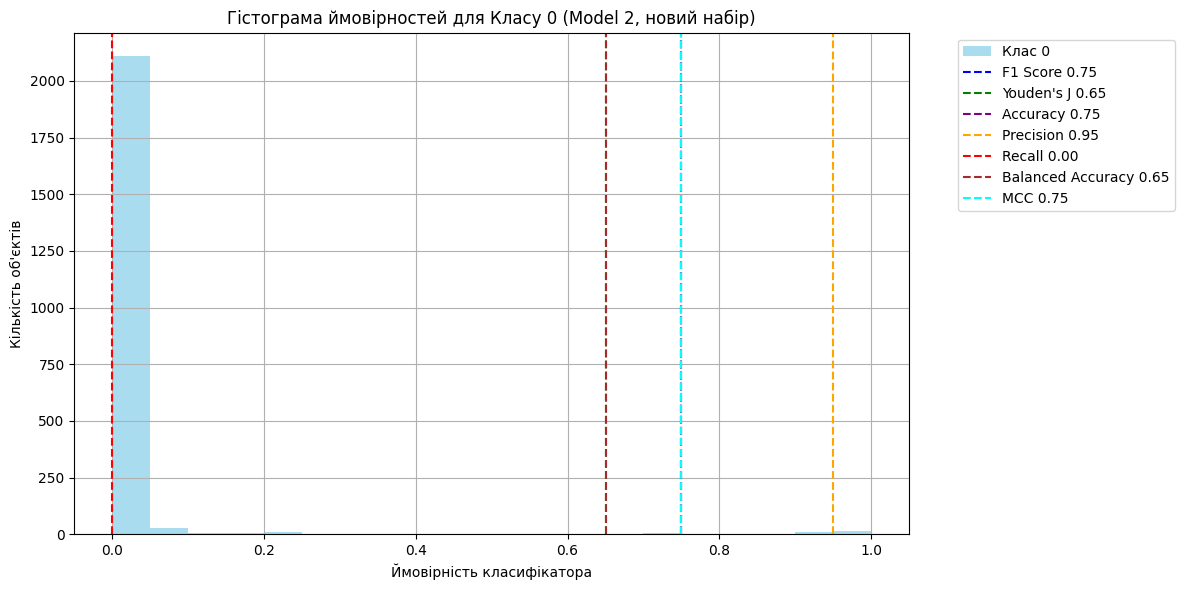

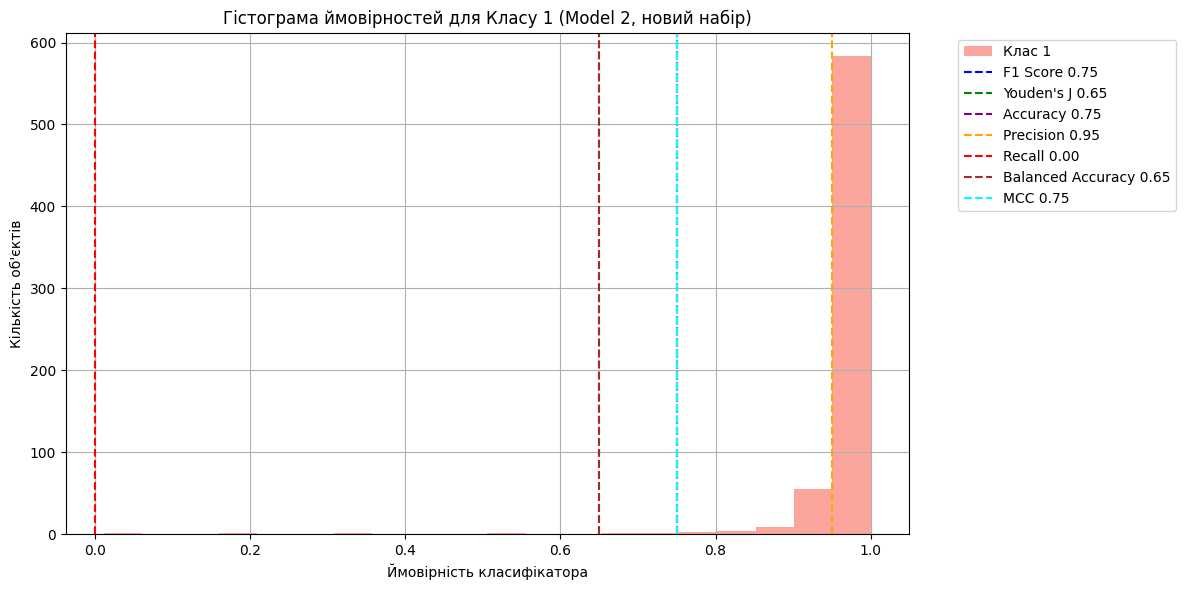

In [21]:
class_0_2r = probs_model2_reduced[y_true_reduced == 0]
class_1_2r = probs_model2_reduced[y_true_reduced == 1]

best_thresholds_2r = {
    "F1 Score": metrics_model2_reduced.loc[metrics_model2_reduced["F1 Score"].idxmax(), "Threshold"],
    "Youden's J": metrics_model2_reduced.loc[metrics_model2_reduced["Youden's J"].idxmax(), "Threshold"],
    "Accuracy": metrics_model2_reduced.loc[metrics_model2_reduced["Accuracy"].idxmax(), "Threshold"],
    "Precision": metrics_model2_reduced.loc[metrics_model2_reduced["Precision"].idxmax(), "Threshold"],
    "Recall": metrics_model2_reduced.loc[metrics_model2_reduced["Recall"].idxmax(), "Threshold"],
    "Balanced Accuracy": metrics_model2_reduced.loc[metrics_model2_reduced["Balanced Accuracy"].idxmax(), "Threshold"],
    "MCC": metrics_model2_reduced.loc[metrics_model2_reduced["MCC"].idxmax(), "Threshold"]
}

plt.figure(figsize=(12, 6))
plt.hist(class_0_2r, bins=20, color='skyblue', alpha=0.7, label="Клас 0")

colors = ['blue', 'green', 'purple', 'orange', 'red', 'brown', 'cyan']
for (metric, thr), color in zip(best_thresholds_2r.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 0 (Model 2, новий набір)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(class_1_2r, bins=20, color='salmon', alpha=0.7, label="Клас 1")

for (metric, thr), color in zip(best_thresholds_2r.items(), colors):
    plt.axvline(thr, color=color, linestyle='--', label=f'{metric} {thr:.2f}')

plt.title("Гістограма ймовірностей для Класу 1 (Model 2, новий набір)")
plt.xlabel("Ймовірність класифікатора")
plt.ylabel("Кількість об'єктів")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Model 2 є кращою, аджке краще розділяє класи навіть після зміни розподілу, 
Кращою метрикою для не згалансованого набору є Balanced Accuracy.

Незбалансованість може покращити Precision, але більшість інших метрик погіршкє